# 04 — Uncertainty and model governance

This notebook turns the point estimates from notebook 03 into valuation ranges and checks the
model against the June 2024 Interagency AVM Quality Control Rule. It uses the same Ames sales and
LightGBM model, refit on a proper training subset with separate rows held back for calibration.
Each property gets an 80% prediction interval: for example, a home valued at $185,000 might carry
a range of $168,000 to $205,000, and *coverage* is the share of sales whose price actually falls
inside its range. §1 shows that a coverage figure quoted from one test set is not a validated
interval, which took resampling to demonstrate, and notebook 08 converts the interval width
into a credit cost.

Terms are defined in [the glossary](../docs/GLOSSARY.md).

The notebook covers four things:

1. **A per-property 80% valuation range** from split-conformal prediction, a method that assumes
   almost nothing about the error distribution and calibrates the range on how wrong the model was
   on held-out houses. Its empirical coverage is validated rather than assumed.
2. **An AVM scorecard** against the thresholds institutional models are held to.
3. **A governance section** mapped to the Interagency AVM Quality Control
   Rule, including the agencies' added fifth factor, nondiscrimination, operationalised
   as error-parity testing.
4. **Moran's I on the residuals**, a test of whether errors cluster geographically. Unmodelled
   spatial autocorrelation is a real AVM failure mode and a concrete candidate for what to fix next.

In [1]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

from ames.avm import (ConformalValuation, ConformalizedQuantileRegression,
                      MondrianConformal, duan_smearing_factor, error_parity, mdape,
                      mean_signed_error, morans_i, parity_gap, passes_industry_thresholds,
                      ppe, predict_dollars, scorecard, split_calibration)
from ames.compat import silence_spurious_matmul_warnings, worker_warning_filter
from ames.config import (ARMS_LENGTH_CONDITION, CONFORMAL_ALPHA, MDAPE_THRESHOLD,
                         PPE10_THRESHOLD, PROCESSED, RANDOM_TEST_SIZE, SEED)
from ames.data import load_properties
from ames.features import prepare
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
os.environ["PYTHONWARNINGS"] = worker_warning_filter()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "04 · Uncertainty & governance"
SOURCE = "Source: De Cock (2011) · 862 held-out arm's-length sales, 2009 – July 2010."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

artifacts = joblib.load(PROCESSED / "avm_model.joblib")
predictions = pd.read_parquet(PROCESSED / "avm_predictions.parquet")
summary = json.loads((PROCESSED / "avm_summary.json").read_text())
MODEL = artifacts["model_name"]
print(f"best model from notebook 03: {MODEL}")
print(f"temporal MdAPE {summary['mdape_temporal']:.2%} · PPE10 {summary['ppe10_temporal']:.1%}")

best model from notebook 03: LightGBM
temporal MdAPE 5.49% · PPE10 76.6%


## 1. Split-conformal prediction intervals

### Why not the textbook prediction interval

The OLS prediction interval is valid only if the residuals are homoskedastic and
Gaussian. Notebook 01 showed they are neither, so the coverage guarantee of that interval
does not apply here.

Split conformal (Lei et al., 2018) assumes nothing about the residual distribution.
It requires only that calibration rows be *exchangeable* with the rows being predicted,
and in exchange gives a finite-sample guarantee that coverage is at least 1 − α.

The procedure needs a three-way split, so the model from notebook 03 is refit here on a
proper training subset with the remainder held back purely for calibration. Nothing
in the calibration set influences the fit.

In [2]:
data = prepare(load_properties())
universe = data[(data["Sale Condition"] == ARMS_LENGTH_CONDITION)
                & (~data["is_outlier_grlivarea"])].copy()
y_log = np.log(universe["SalePrice"])

from sklearn.model_selection import train_test_split
random_train_idx, random_test_idx = train_test_split(
    universe.index, test_size=RANDOM_TEST_SIZE, random_state=SEED)
REGIMES = {
    "random": (random_train_idx, random_test_idx),
    "temporal": (universe.index[universe["temporal_split"] == "train"],
                 universe.index[universe["temporal_split"] == "test"]),
}

#: Valuation bands for the Mondrian interval -- the variant the adaptive-width comparison
#: below recommends, and the one `make promote` serves.  Quintiles of the calibration-set
#: valuation.
MONDRIAN_BINS = 5


def calibrate_once(train_idx, test_idx, seed: int):
    """Fit on a proper-train half, calibrate on the other half, predict the test set.

    Duan smearing is folded into the log prediction as ``+ log(smearing)`` rather than
    applied afterwards in dollars.  That keeps one definition of the point estimate, so
    coverage measured in log space and coverage measured against the dollar interval are
    the same number rather than differing by the smearing factor.
    """
    proper_idx, calib_idx = split_calibration(train_idx, calib_fraction=0.5, seed=seed)

    estimator = clone(artifacts["estimator"])
    estimator.fit(universe.loc[proper_idx], y_log.loc[proper_idx])

    smear = duan_smearing_factor(y_log.loc[proper_idx]
                                 - estimator.predict(universe.loc[proper_idx]))
    log_smear = np.log(smear)

    calib_pred = estimator.predict(universe.loc[calib_idx]) + log_smear
    cv = ConformalValuation(alpha=CONFORMAL_ALPHA).calibrate(y_log.loc[calib_idx], calib_pred)

    # The served interval: same calibration rows, one half-width per valuation band.
    mondrian = MondrianConformal(CONFORMAL_ALPHA, n_bins=MONDRIAN_BINS).calibrate(
        y_log.loc[calib_idx], calib_pred)

    test_pred = estimator.predict(universe.loc[test_idx]) + log_smear
    lo, hi = cv.interval_dollars(test_pred)
    m_lo, m_hi = mondrian.interval_dollars(test_pred)
    return {
        "conformal": cv, "mondrian": mondrian, "estimator": estimator, "smearing": smear,
        "proper_n": len(proper_idx), "calib_n": len(calib_idx),
        "test_idx": test_idx, "log_pred": test_pred,
        "dollars": np.exp(test_pred),
        "actual": np.exp(y_log.loc[test_idx].to_numpy()),
        "lo": lo, "hi": hi, "m_lo": m_lo, "m_hi": m_hi,
        "coverage": cv.coverage(y_log.loc[test_idx], test_pred),
        "mondrian_coverage": mondrian.coverage(y_log.loc[test_idx], test_pred),
    }

conformal = {}
for regime, (train_idx, test_idx) in REGIMES.items():
    conformal[regime] = calibrate_once(train_idx, test_idx, SEED)
    cv = conformal[regime]["conformal"]
    print(f"{regime:9s} proper-train {conformal[regime]['proper_n']:5d} · "
          f"calibration {conformal[regime]['calib_n']:5d} · q={cv.q_:.4f} · "
          f"relative width {cv.relative_width:.1%} · "
          f"coverage {conformal[regime]['coverage']:.1%} "
          f"(Mondrian {conformal[regime]['mondrian_coverage']:.1%})")

random    proper-train   904 · calibration   905 · q=0.0988 · relative width 19.8% · coverage 73.3% (Mondrian 75.8%)


temporal  proper-train   775 · calibration   775 · q=0.1048 · relative width 21.0% · coverage 76.3% (Mondrian 76.7%)


### Does the guarantee hold?

Nominal coverage is 80%. Conformal guarantees at least that, so over-coverage is
expected and fine; under-coverage is the failure mode.

In [3]:
coverage_table = pd.DataFrame({
    regime: {
        "nominal coverage": 1 - CONFORMAL_ALPHA,
        "empirical coverage": r["coverage"],
        "gap": r["coverage"] - (1 - CONFORMAL_ALPHA),
        "interval half-width (log)": r["conformal"].q_,
        "interval as % of value": r["conformal"].relative_width,
        "median interval width ($)": float(np.median(r["hi"] - r["lo"])),
        "calibration n": r["calib_n"],
    } for regime, r in conformal.items()
}).T
coverage_table.round(4)

,nominal coverage,empirical coverage,gap,interval half-width (log),interval as % of value,median interval width ($),calibration n
random,0.8,0.7330,-0.0670,0.0988,0.1979,30439.5339,905.0
temporal,0.8,0.7633,-0.0367,0.1048,0.2099,34000.1332,775.0


**Both regimes come in below 80% on this particular split.** That does not by itself refute
the guarantee, and the distinction is tested below.

Conformal validity is marginal over the draw of the calibration set: coverage is at
least 1 − α in expectation, not on every realisation. On a single 603-row test set
the empirical coverage is a binomial proportion with a standard error near 1.6
percentage points, and the interval half-width `q` is itself an estimated quantile that
adds further variance. One number cannot distinguish "the method is broken" from
"this draw was unlucky".

Resampling can.

Two sources of variance have to be separated, and only one of them can be resampled in
both regimes:

- Calibration draw: which rows land in the calibration half. Resampleable everywhere.
- Test draw: which properties end up in the test set at all. Resampleable under the
  random split, but not under the temporal split, where the test set is defined by the
  calendar and there is only one of it.

The method itself is therefore validated on the random split by resampling the whole design,
and the temporal split is then examined holding its fixed test set in place.

In [4]:
REPEATS = 25

# --- validating the method: resample the entire random split ---
full_rows = []
for seed in range(REPEATS):
    tr, te = train_test_split(universe.index, test_size=RANDOM_TEST_SIZE, random_state=seed)
    run = calibrate_once(tr, te, seed)
    full_rows.append({"coverage": run["coverage"], "q": run["conformal"].q_,
                      "relative_width": run["conformal"].relative_width})
full_resample = pd.DataFrame(full_rows)

# --- the calibration-draw component alone, on each regime's fixed test set ---
calib_rows = []
for regime, (train_idx, test_idx) in REGIMES.items():
    for seed in range(REPEATS):
        run = calibrate_once(train_idx, test_idx, seed)
        calib_rows.append({"regime": regime, "coverage": run["coverage"],
                           "relative_width": run["conformal"].relative_width})
calib_resample = pd.DataFrame(calib_rows)

binomial_se = {r: float(np.sqrt((1 - CONFORMAL_ALPHA) * CONFORMAL_ALPHA / len(REGIMES[r][1])))
               for r in REGIMES}

repeat_summary = pd.concat([
    pd.DataFrame({
        "mean_coverage": [full_resample["coverage"].mean()],
        "sd": [full_resample["coverage"].std()],
        "min_coverage": [full_resample["coverage"].min()],
        "max_coverage": [full_resample["coverage"].max()],
        "mean_width": [full_resample["relative_width"].mean()],
        "binomial se": [binomial_se["random"]],
        "resampled": ["train/test split + calibration"],
    }, index=["random (full resample)"]),
    calib_resample.groupby("regime").agg(
        mean_coverage=("coverage", "mean"), sd=("coverage", "std"),
        min_coverage=("coverage", "min"), max_coverage=("coverage", "max"),
        mean_width=("relative_width", "mean"),
    ).assign(**{"binomial se": lambda d: [binomial_se[i] for i in d.index],
                "resampled": "calibration only (test set fixed)"})
    .rename(index={"random": "random (fixed test set)",
                   "temporal": "temporal (fixed test set)"}),
])
repeat_summary.round(4)

,mean_coverage,sd,min_coverage,max_coverage,mean_width,binomial se,resampled
random (full resample),0.8008,0.0207,0.7645,0.8408,0.2184,0.0163,train/test split + calibration
random (fixed test set),0.7661,0.0166,0.7313,0.7944,0.2102,0.0163,calibration only (test set fixed)
temporal (fixed test set),0.7635,0.0140,0.7401,0.7854,0.2161,0.0136,calibration only (test set fixed)


  saved reports/figures/04_coverage_validation.png


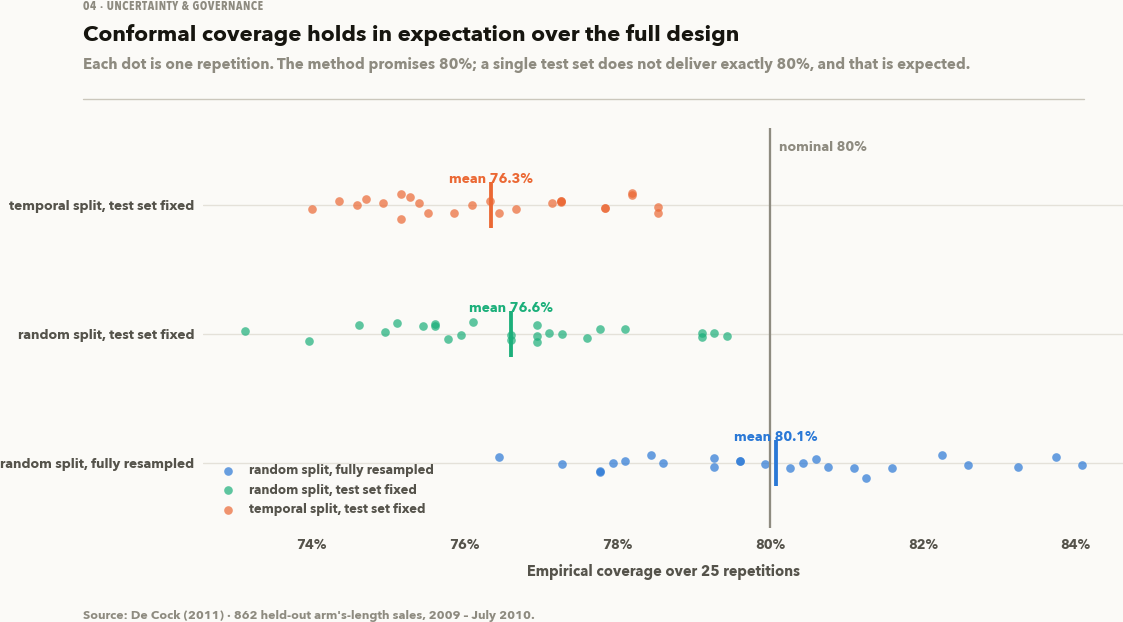

In [5]:
series = [
    ("random split, fully resampled", full_resample["coverage"], BLUE),
    ("random split, test set fixed",
     calib_resample.loc[calib_resample["regime"] == "random", "coverage"], AQUA),
    ("temporal split, test set fixed",
     calib_resample.loc[calib_resample["regime"] == "temporal", "coverage"], ORANGE),
]
jitter = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
for i, (label, vals, color) in enumerate(series):
    ax.scatter(vals, np.full(len(vals), i) + jitter.normal(0, 0.05, len(vals)),
               s=32, color=color, alpha=0.7, linewidths=0, label=label)
    ax.scatter([vals.mean()], [i], marker="|", s=900, color=color, linewidths=2.5)
    annotate(ax, vals.mean(), i, f"mean {vals.mean():.1%}", color=color,
             offset=(0, 17), ha="center")
ax.axvline(1 - CONFORMAL_ALPHA, color=INK_MUTED, lw=1.5)
annotate(ax, 1 - CONFORMAL_ALPHA, 2.45, f"nominal {1 - CONFORMAL_ALPHA:.0%}",
         color=INK_MUTED, offset=(6, 0))
ax.set_yticks(range(len(series)), [s[0] for s in series], fontsize=9)
ax.set_ylim(-0.5, 2.6)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel(f"Empirical coverage over {REPEATS} repetitions")
ax.legend(loc="lower left", fontsize=8.5)
finish(fig, "Conformal coverage holds in expectation over the full design",
       "Each dot is one repetition. The method promises 80%; a single test set does not "
       "deliver exactly 80%, and that is expected.")
save(fig, "04_coverage_validation")
plt.show()

**Resampling the whole random design recovers the guarantee: mean coverage lands on
nominal.** The method does what it claims.

Holding a particular test set fixed does not, and the two middle rows show why. The
603-row random test set used above happens to be harder than average. Resampling only
its calibration half moves coverage around by a point or two but cannot average away the
difficulty of the test rows themselves. The single-split number reported earlier is
one draw from a distribution whose mean is 80%, not evidence that the intervals are
miscalibrated.

This applies beyond this project. **A coverage number quoted from one
holdout is not a validated interval.** With 603 rows the binomial standard error alone
is 1.6 points before any of the variance from estimating `q`, so an AVM vendor quoting
"80% coverage" from a single sample is quoting a number with several points of slack.

The temporal split has a structural problem on top of that. Conformal validity requires
the calibration rows to be exchangeable with the rows being predicted, and under a
temporal split that is violated by construction: 2009–2010 sales are not exchangeable
with 2006–2008 sales. The gap that remains after averaging out the resampling noise is
the cost of that violation. It measures how much the guarantee degrades under the kind of
distribution shift an AVM faces in production.

This has an operational consequence: if intervals under-cover when
the market moves, the calibration set has to be recent, not merely held out. That argues
for rolling recalibration on a trailing window rather than a one-time fit.

  saved reports/figures/04_conformal_intervals.png


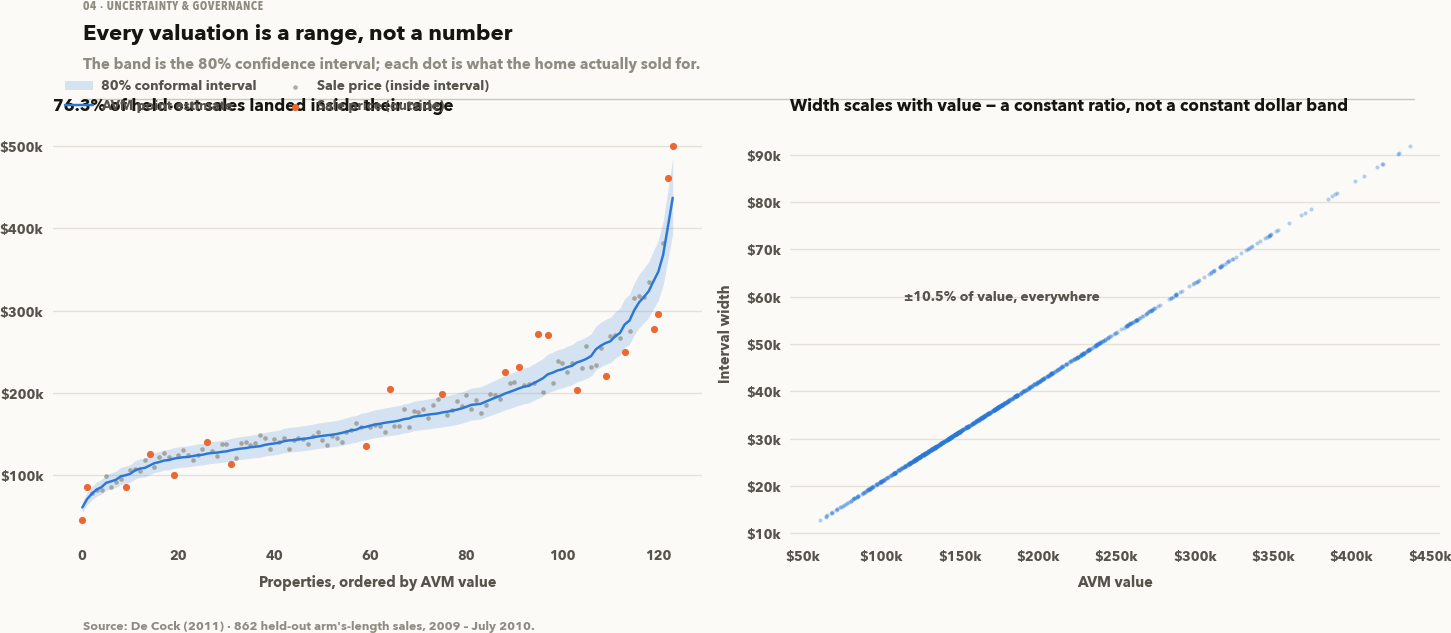

In [6]:
best_regime = "temporal"
r = conformal[best_regime]
test_rows = universe.loc[r["test_idx"]]
frame = pd.DataFrame({
    "actual": r["actual"], "predicted": r["dollars"], "lo": r["lo"], "hi": r["hi"],
    "lo_mondrian": r["m_lo"], "hi_mondrian": r["m_hi"],
    "q_mondrian": r["mondrian"].half_width(r["log_pred"]),
    "band_mondrian": r["mondrian"].band(r["log_pred"]) + 1,
    "Neighborhood": test_rows["Neighborhood"].to_numpy(),
    "Latitude": test_rows["Latitude"].to_numpy(),
    "Longitude": test_rows["Longitude"].to_numpy(),
    "Gr Liv Area": test_rows["Gr Liv Area"].to_numpy(),
}, index=r["test_idx"])
frame["covered"] = (frame["actual"] >= frame["lo"]) & (frame["actual"] <= frame["hi"])
frame["pe"] = (frame["predicted"] - frame["actual"]) / frame["actual"]
frame["width"] = frame["hi"] - frame["lo"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.3))

sample = frame.sort_values("predicted").iloc[::7].reset_index(drop=True)
x = np.arange(len(sample))
axes[0].fill_between(x, sample["lo"], sample["hi"], color=BLUE, alpha=0.18, lw=0,
                     label=f"{1 - CONFORMAL_ALPHA:.0%} conformal interval")
axes[0].plot(x, sample["predicted"], color=BLUE, lw=1.6, label="AVM point estimate")
inside, outside = sample[sample["covered"]], sample[~sample["covered"]]
axes[0].scatter(inside.index, inside["actual"], s=9, color=INK_MUTED, alpha=0.7,
                linewidths=0, label="Sale price (inside interval)")
axes[0].scatter(outside.index, outside["actual"], s=22, color=ORANGE,
                linewidths=0, label="Sale price (outside)")
axes[0].yaxis.set_major_formatter(money)
axes[0].set_xlabel("Properties, ordered by AVM value")
legend_above(axes[0], ncol=2)
titled(axes[0], f"{r['coverage']:.1%} of held-out sales landed inside their range")

axes[1].scatter(frame["predicted"], frame["width"], s=7, alpha=0.35,
                color=BLUE, linewidths=0)
axes[1].xaxis.set_major_formatter(money)
axes[1].yaxis.set_major_formatter(money)
axes[1].set_xlabel("AVM value")
axes[1].set_ylabel("Interval width")
titled(axes[1], "Width scales with value — a constant ratio, not a constant dollar band")
annotate(axes[1], frame["predicted"].quantile(0.1), frame["width"].quantile(0.92),
         f"±{r['conformal'].relative_width / 2:.1%} of value, everywhere",
         color=INK_SECONDARY, offset=(6, 0))
finish(fig, "Every valuation is a range, not a number",
       "The band is the 80% confidence interval; each dot is what the home actually sold for.")
save(fig, "04_conformal_intervals")
plt.show()

The right-hand panel shows why the intervals are built in log space: a $500k home gets a wider
dollar band than a $150k home, because valuation error scales with price. An additive
interval would have been too wide at the bottom of the book and too narrow at the top,
where loss severity is highest.

### Conditional coverage

Conformal guarantees marginal coverage, across the whole population. It does not
promise coverage within any particular segment, and the difference matters: a lender
does not hold the average of its book, it holds specific loans in specific places.

  saved reports/figures/04_conditional_coverage.png


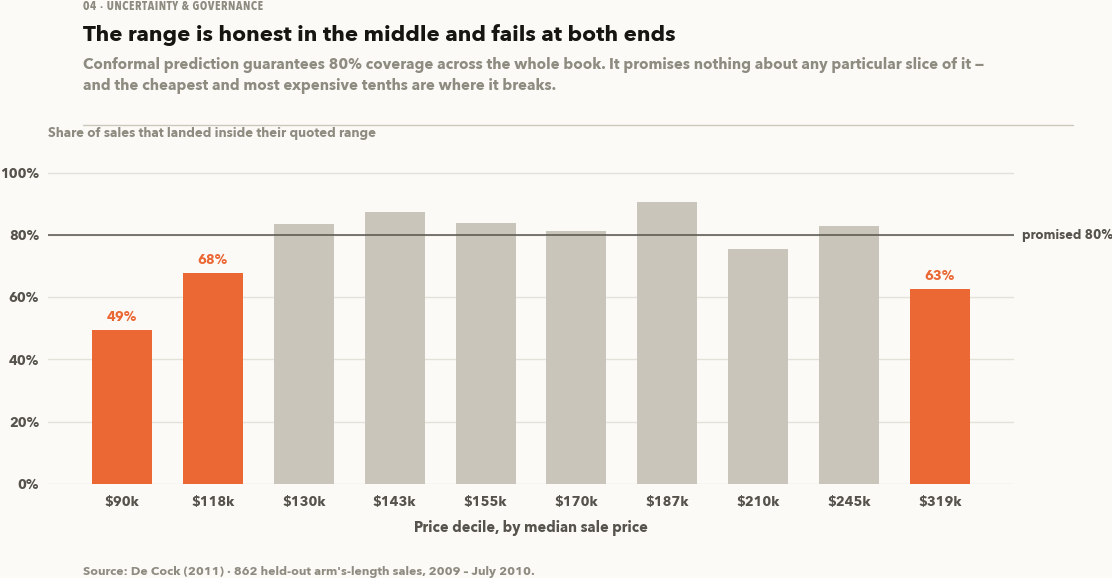

In [7]:
frame["price_decile"] = pd.qcut(frame["actual"], 10, labels=False)
by_decile = frame.groupby("price_decile").agg(
    n=("covered", "size"), median_price=("actual", "median"),
    coverage=("covered", "mean"), median_width=("width", "median"),
    bias=("pe", "mean"))

fig, ax = plt.subplots(figsize=(10.4, 5.8))
nominal = 1 - CONFORMAL_ALPHA
# Colour only the deciles that miss: they are the finding, the rest are context.
fails = by_decile["coverage"] < nominal - 0.08
ax.bar(by_decile.index, by_decile["coverage"], width=0.66,
       color=[CONTRAST if f else CONTEXT for f in fails])
reference_line(ax, nominal, f"promised {nominal:.0%}", color=INK_SECONDARY)
for i, (cov, fail) in enumerate(zip(by_decile["coverage"], fails)):
    if fail:
        ax.annotate(f"{cov:.0%}", (i, cov), xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=9, color=CONTRAST, fontweight="demibold")
ax.set_xticks(by_decile.index, [money(p) for p in by_decile["median_price"]])
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0, 1.06)
ax.set_xlabel("Price decile, by median sale price")
axis_note(ax, "Share of sales that landed inside their quoted range")
finish(fig, "The range is honest in the middle and fails at both ends",
       "Conformal prediction guarantees 80% coverage across the whole book. It promises "
       "nothing about any particular slice of it — and the cheapest and most expensive "
       "tenths are where it breaks.")
save(fig, "04_conditional_coverage")
plt.show()

In [8]:
by_decile.round(4)

,n,median_price,coverage,median_width,bias
price_decile,,,,,
0,87,90000.0,0.4943,19714.7319,0.1024
1,90,118000.0,0.6778,25125.1401,0.0314
2,85,130000.0,0.8353,26923.4787,-0.0017
3,86,142575.0,0.8721,29927.5886,-0.0003
4,86,154650.0,0.8372,31889.9731,-0.0085
5,85,170000.0,0.8118,35131.6277,-0.0074
6,84,187050.0,0.9048,38511.9950,-0.0080
7,86,210000.0,0.7558,43614.9768,-0.0126
8,87,245000.0,0.8276,50325.7713,-0.0152


### Adaptive interval width

The global interval applies one half-width to every property, and the table above shows
the cost: coverage in the cheapest decile is roughly half the promised rate, and the most
expensive decile also falls well short. Two recognised remedies let the width vary. Both
are tested here on the same 25 proper/calibration splits used above.

- Mondrian conformal calibrates a separate half-width per group, which extends the
  coverage guarantee to hold within each group. The grouping must be observable when a
  valuation is issued, so the sale-price deciles used above are inadmissible as a
  grouping: the sale price is the quantity being estimated. Two admissible groupings are
  tested: quintiles of the model's own valuation, and neighbourhood.
- Conformalized quantile regression (CQR) fits LightGBM at the 10th and 90th
  conditional quantiles of log price, then conformalizes the resulting band, so width
  varies per property. The uncalibrated quantile band is reported alongside it, to
  isolate what the conformal step contributes.

In [9]:
QUANTILE_LEVELS = (CONFORMAL_ALPHA / 2, 1 - CONFORMAL_ALPHA / 2)
METHOD_ORDER = ["Global", "Mondrian · value", "Mondrian · neighbourhood", "CQR",
                "Quantile models, uncalibrated"]


def adaptive_once(train_idx, test_idx, seed: int) -> list[dict]:
    """Every interval method on one proper/calibration split, scored on the fixed test set.

    The point estimator is refitted per split exactly as ``calibrate_once`` does, so the
    global row here reproduces the coverage study above rather than approximating it.
    """
    proper_idx, calib_idx = split_calibration(train_idx, calib_fraction=0.5, seed=seed)
    X_proper, X_calib, X_test = (universe.loc[i] for i in (proper_idx, calib_idx, test_idx))
    y_proper = y_log.loc[proper_idx]

    estimator = clone(artifacts["estimator"]).fit(X_proper, y_proper)
    log_smear = np.log(duan_smearing_factor(y_proper - estimator.predict(X_proper)))
    pc = estimator.predict(X_calib) + log_smear
    pt = estimator.predict(X_test) + log_smear
    yc, yt = y_log.loc[calib_idx].to_numpy(), y_log.loc[test_idx].to_numpy()
    nb_c, nb_t = X_calib["Neighborhood"].to_numpy(), X_test["Neighborhood"].to_numpy()

    bands = {
        "Global": ConformalValuation(CONFORMAL_ALPHA).calibrate(yc, pc).interval_log(pt),
        "Mondrian · value": MondrianConformal(CONFORMAL_ALPHA, n_bins=MONDRIAN_BINS)
            .calibrate(yc, pc).interval_log(pt),
        "Mondrian · neighbourhood": MondrianConformal(CONFORMAL_ALPHA, min_group=30)
            .calibrate(yc, pc, groups=nb_c).interval_log(pt, groups=nb_t),
    }

    # Quantile models predict log-price quantiles directly: no smearing, because
    # quantiles survive the exp() transform and means do not.
    quantiles = {}
    for level in QUANTILE_LEVELS:
        q_est = clone(artifacts["estimator"]).set_params(
            model__objective="quantile", model__alpha=level)
        q_est.fit(X_proper, y_proper)
        quantiles[level] = (q_est.predict(X_calib), q_est.predict(X_test))
    (lo_c, lo_t), (hi_c, hi_t) = quantiles[QUANTILE_LEVELS[0]], quantiles[QUANTILE_LEVELS[1]]
    bands["Quantile models, uncalibrated"] = (np.minimum(lo_t, hi_t), np.maximum(lo_t, hi_t))
    bands["CQR"] = (ConformalizedQuantileRegression(CONFORMAL_ALPHA)
                    .calibrate(yc, lo_c, hi_c).interval_log(lo_t, hi_t))

    decile = pd.qcut(yt, 10, labels=False)
    rows = []
    for method, (lo, hi) in bands.items():
        inside = (yt >= lo) & (yt <= hi)
        by_dec = pd.Series(inside).groupby(decile).mean()
        rows.append({
            "method": method, "seed": seed, "coverage": inside.mean(),
            "relative_width": float(np.mean(np.exp(hi - pt) - np.exp(lo - pt))),
            "width_dispersion": float(np.std(hi - lo) / np.mean(hi - lo)),
            "bottom_decile": by_dec.iloc[0], "top_decile": by_dec.iloc[-1],
            "decile_deviation": float(np.mean(np.abs(by_dec - (1 - CONFORMAL_ALPHA)))),
            **{f"d{k}": v for k, v in by_dec.items()},
        })
    return rows


train_idx, test_idx = REGIMES["temporal"]
adaptive_runs = pd.DataFrame([row for seed in range(REPEATS)
                              for row in adaptive_once(train_idx, test_idx, seed)])
METRICS = ["coverage", "relative_width", "width_dispersion", "bottom_decile",
           "top_decile", "decile_deviation"]
adaptive = adaptive_runs.groupby("method")[METRICS].mean().loc[METHOD_ORDER]
adaptive_sd = adaptive_runs.groupby("method")[METRICS].std().loc[METHOD_ORDER]
print(f"temporal regime · {REPEATS} splits · mean (sd across splits)\n")
print(pd.DataFrame({m: [f"{a:.3f} ({s:.3f})" for a, s in zip(adaptive[m], adaptive_sd[m])]
                    for m in METRICS}, index=METHOD_ORDER).to_string())

temporal regime · 25 splits · mean (sd across splits)

                                    coverage relative_width width_dispersion  bottom_decile     top_decile decile_deviation
Global                         0.763 (0.014)  0.216 (0.007)    0.000 (0.000)  0.512 (0.048)  0.707 (0.037)    0.082 (0.010)
Mondrian · value               0.772 (0.015)  0.222 (0.009)    0.171 (0.037)  0.626 (0.056)  0.745 (0.027)    0.065 (0.011)
Mondrian · neighbourhood       0.765 (0.019)  0.225 (0.008)    0.289 (0.030)  0.612 (0.046)  0.687 (0.040)    0.077 (0.014)
CQR                            0.798 (0.015)  0.296 (0.009)    0.461 (0.032)  0.559 (0.052)  0.676 (0.045)    0.085 (0.012)
Quantile models, uncalibrated  0.577 (0.018)  0.204 (0.007)    0.668 (0.029)  0.437 (0.054)  0.493 (0.057)    0.222 (0.018)


  saved reports/figures/04_adaptive_intervals.png


/Users/mohona/DS/Portfolio/real-estate-valuation-risk/src/ames/viz.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


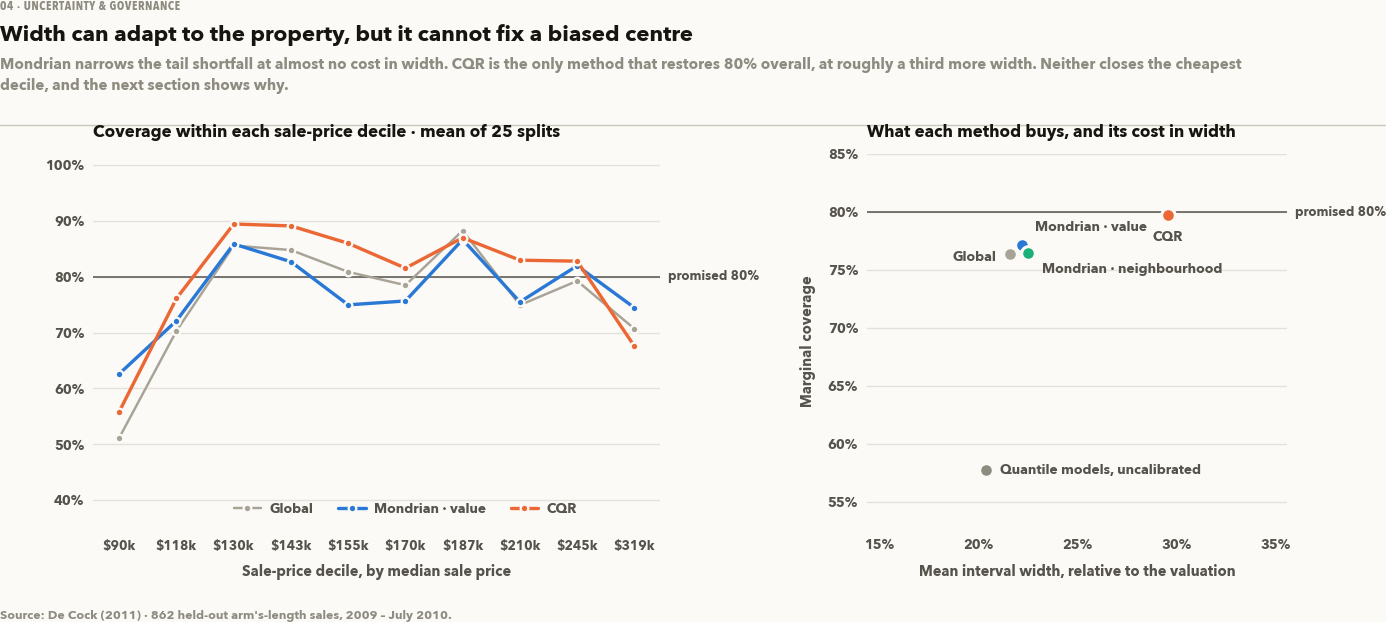

In [10]:
nominal = 1 - CONFORMAL_ALPHA
decile_cov = adaptive_runs.groupby("method")[[f"d{k}" for k in range(10)]].mean()
decile_cov.columns = range(10)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.2),
                         gridspec_kw={"width_ratios": [1.35, 1.0], "wspace": 0.42})

ax = axes[0]
for method, color, lw in [("Global", CONTEXT_DARK, 1.6),
                          ("Mondrian · value", SUBJECT, 2.2),
                          ("CQR", CONTRAST, 2.2)]:
    ax.plot(decile_cov.columns, decile_cov.loc[method], color=color, lw=lw,
            marker="o", ms=5, markeredgecolor=SURFACE, markeredgewidth=1.5, label=method)
reference_line(ax, nominal, f"promised {nominal:.0%}", color=INK_SECONDARY)
ax.set_xticks(range(10), [money(p) for p in by_decile["median_price"]])
ax.tick_params(axis="x", labelsize=8.5)
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0.35, 1.02)
ax.set_xlabel("Sale-price decile, by median sale price")
# The lower band of the panel is empty below every line except the cheapest decile, so the
# legend goes there rather than above, where it would collide with the panel heading.
ax.legend(loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.55, 0.0))
titled(ax, f"Coverage within each sale-price decile · mean of {REPEATS} splits")

ax = axes[1]
# Three methods land within a point of each other, so their labels are placed by hand
# rather than on a shared offset -- a shared offset stacks them into one unreadable blot.
placement = {
    "Global": dict(offset=(-9, -2), ha="right"),
    "Mondrian · value": dict(offset=(9, 11), ha="left"),
    "Mondrian · neighbourhood": dict(offset=(9, -11), ha="left"),
    "CQR": dict(offset=(0, -15), ha="center"),
    "Quantile models, uncalibrated": dict(offset=(9, 0), ha="left"),
}
colours = {"Global": CONTEXT_DARK, "Mondrian · value": SUBJECT,
           "Mondrian · neighbourhood": AQUA, "CQR": CONTRAST,
           "Quantile models, uncalibrated": INK_MUTED}
for method in METHOD_ORDER:
    row = adaptive.loc[method]
    ax.scatter(row["relative_width"], row["coverage"], s=80, color=colours[method],
               edgecolor=SURFACE, linewidth=2, zorder=4)
    annotate(ax, row["relative_width"], row["coverage"], method, **placement[method])
reference_line(ax, nominal, f"promised {nominal:.0%}", color=INK_SECONDARY)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)
ax.set_xlim(adaptive["relative_width"].min() - 0.06, adaptive["relative_width"].max() + 0.06)
ax.set_ylim(adaptive["coverage"].min() - 0.05, max(nominal, adaptive["coverage"].max()) + 0.05)
ax.set_xlabel("Mean interval width, relative to the valuation")
ax.set_ylabel("Marginal coverage")
titled(ax, "What each method buys, and its cost in width")

finish(fig, "Width can adapt to the property, but it cannot fix a biased centre",
       "Mondrian narrows the tail shortfall at almost no cost in width. CQR is the only "
       "method that restores 80% overall, at roughly a third more width. Neither closes "
       "the cheapest decile, and the next section shows why.")
save(fig, "04_adaptive_intervals")
plt.show()

On the temporal holdout, averaged over 25 splits:

| Method | Coverage | Mean width | Cheapest decile | Top decile | Mean decile deviation |
|---|---:|---:|---:|---:|---:|
| Global | 76.3% | 21.6% | 51.2% | 70.7% | 8.2 pt |
| Mondrian · value | 77.2% | 22.2% | **62.6%** | **74.5%** | **6.5 pt** |
| Mondrian · neighbourhood | 76.5% | 22.5% | 61.2% | 68.7% | 7.7 pt |
| CQR | **79.8%** | 29.6% | 55.9% | 67.6% | 8.5 pt |
| Quantile models, uncalibrated | 57.7% | 20.4% | 43.7% | 49.3% | 22.2 pt |

- Mondrian by valuation is the best conditional fix. It lifts the cheapest decile by 11
  points and the top by 4, cuts the average decile deviation by a fifth, and costs 0.6
  points of width. It is the recommended default.
- CQR is the only method that restores the marginal rate, at 79.8%, but it needs
  37% more width and does not improve the tails. Its extra width goes where the
  quantile models see difficulty, which is not where the sale-price tails are.
- The conformal step is necessary. The same quantile models, uncalibrated, cover
  57.7% against the 80% they target; CQR's calibration adds 22 points.
- No method closes the cheapest decile. Every interval is centred on the point
  estimate, and a symmetric band cannot efficiently cover a one-sided miss. In the
  cheapest decile the misses are almost all in one direction, which raises the question of
  whether that reflects the model or the measurement.

   by sale-price decile  by valuation decile  unbiased, one spread  unbiased, measured spreads
0                0.1024               0.0229                0.0561                      0.0757
1                0.0314              -0.0107                0.0352                      0.0349
2               -0.0017               0.0091                0.0233                      0.0165
3               -0.0003               0.0030                0.0162                      0.0046
4               -0.0085               0.0277                0.0082                     -0.0046
5               -0.0074               0.0072                0.0012                     -0.0064
6               -0.0080              -0.0131               -0.0068                     -0.0063
7               -0.0126              -0.0005               -0.0149                     -0.0069
8               -0.0152               0.0017               -0.0234                     -0.0142
9               -0.0384              -0.0029      

  saved reports/figures/04_decile_bias_artefact.png


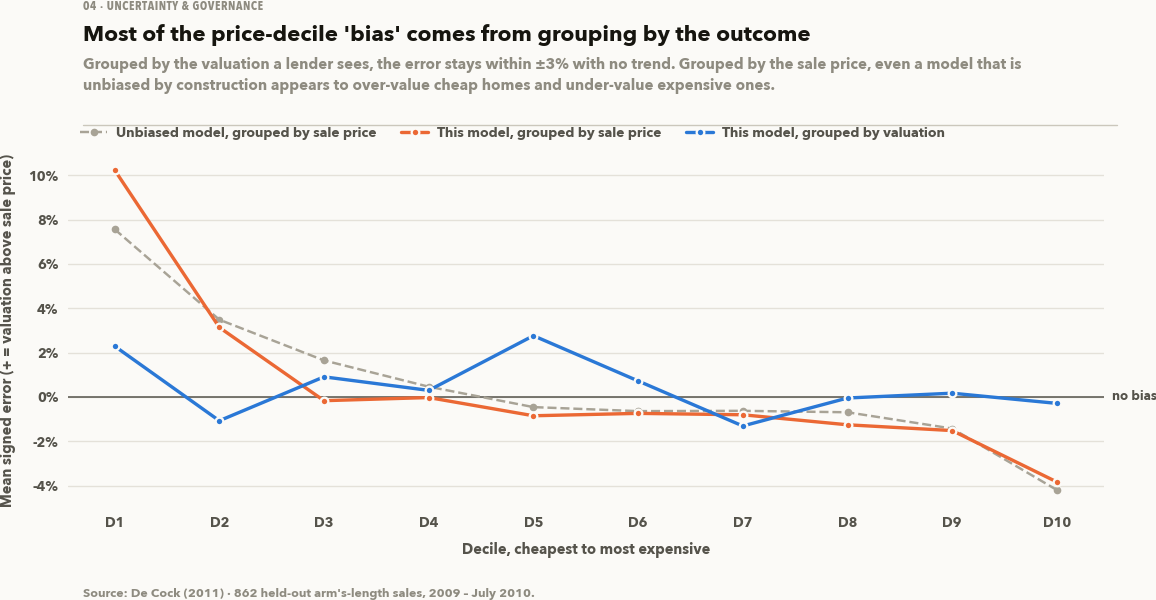

In [11]:
# The same predictions, the same errors, grouped two ways.  The only difference is which
# variable defines the decile -- the outcome, or the quantity a lender actually observes.
diag = frame[["actual", "predicted", "pe"]].copy()
diag["log_err"] = np.log(diag["predicted"] / diag["actual"])
bias_by_outcome = diag.groupby(pd.qcut(diag["actual"], 10, labels=False))["pe"].mean()
bias_by_valuation = diag.groupby(pd.qcut(diag["predicted"], 10, labels=False))["pe"].mean()

# Null model: a predictor that is unbiased by construction -- E[sale | valuation] equals
# the valuation exactly -- carrying this model's own error dispersion.  Whatever pattern
# it shows when grouped by outcome is produced by the grouping, not by any defect.
#
# Two versions.  The homoskedastic one uses a single error spread and is a lower bound.
# The heteroskedastic one gives each valuation quintile its own measured spread, since
# errors are measurably wider for cheaper homes -- and a wider spread at the bottom
# produces a larger artefact exactly where the observed "bias" is largest.
rng = np.random.default_rng(SEED)
log_val = np.log(diag["predicted"])
quintile = pd.qcut(diag["predicted"], 5, labels=False)
fsd_by_valuation = diag.groupby(quintile)["log_err"].std()
edges = np.quantile(log_val, np.linspace(0, 1, 6))[1:-1]


def unbiased_null(heteroskedastic: bool, n: int = 200_000) -> pd.Series:
    sim_val = rng.normal(log_val.mean(), log_val.std(), n)
    spread = (fsd_by_valuation.to_numpy()[np.digitize(sim_val, edges)] if heteroskedastic
              else np.full(n, diag["log_err"].std()))
    sim_sale = sim_val + rng.normal(0, spread)
    return (pd.Series(np.exp(sim_val - sim_sale) - 1)
            .groupby(pd.qcut(sim_sale, 10, labels=False)).mean())


bias_artefact_homo = unbiased_null(heteroskedastic=False)
bias_artefact = unbiased_null(heteroskedastic=True)

bias_table = pd.DataFrame({"by sale-price decile": bias_by_outcome,
                           "by valuation decile": bias_by_valuation,
                           "unbiased, one spread": bias_artefact_homo,
                           "unbiased, measured spreads": bias_artefact})
print(bias_table.round(4).to_string())
print(f"\nlargest |bias| by valuation decile: {bias_by_valuation.abs().max():.1%}")
print("error dispersion (FSD) by valuation quintile, cheapest first:",
      " · ".join(f"{v:.3f}" for v in fsd_by_valuation))
print(f"cheapest decile: observed {bias_by_outcome.iloc[0]:+.1%} · artefact "
      f"{bias_artefact_homo.iloc[0]:+.1%} (one spread) to {bias_artefact.iloc[0]:+.1%} "
      f"(measured spreads) · unexplained {bias_by_outcome.iloc[0] - bias_artefact.iloc[0]:+.1%}")
print(f"top decile:      observed {bias_by_outcome.iloc[-1]:+.1%} · artefact "
      f"{bias_artefact.iloc[-1]:+.1%} · unexplained {bias_by_outcome.iloc[-1] - bias_artefact.iloc[-1]:+.1%}")

fig, ax = plt.subplots(figsize=(10.8, 6.0))
x = np.arange(10)
ax.plot(x, bias_artefact, color=CONTEXT_DARK, lw=1.6, ls="--", marker="o", ms=4,
        label="Unbiased model, grouped by sale price")
ax.plot(x, bias_by_outcome, color=CONTRAST, lw=2.2, marker="o", ms=5,
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="This model, grouped by sale price")
ax.plot(x, bias_by_valuation, color=SUBJECT, lw=2.2, marker="o", ms=5,
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="This model, grouped by valuation")
reference_line(ax, 0.0, "no bias", color=INK_SECONDARY)
ax.set_xticks(x, [f"D{k + 1}" for k in x])
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Decile, cheapest to most expensive")
ax.set_ylabel("Mean signed error (+ = valuation above sale price)")
legend_above(ax, ncol=3)
finish(fig, "Most of the price-decile 'bias' comes from grouping by the outcome",
       "Grouped by the valuation a lender sees, the error stays within ±3% with no "
       "trend. Grouped by the sale price, even a model that is unbiased by "
       "construction appears to over-value cheap homes and under-value expensive ones.")
save(fig, "04_decile_bias_artefact")
plt.show()

**Correction to the price-decile finding.** Notebooks 03 and 04 previously reported that
the model over-values the cheapest decile by 10.2% and under-values the most expensive by
3.8%, and treated this as a model defect with credit consequences. Most of that pattern is
produced by grouping on the sale price, the quantity being estimated.

The mechanism is regression to the mean in the evaluation, not in the model. A sale
lands in the cheapest decile partly *because* its price came in below its valuation, so
grouping by outcome selects on the error. A predictor that is unbiased by construction,
with this model's measured error spread, shows the same shape: +7.6% at the bottom and
−4.2% at the top.

| | Observed, by sale price | Unbiased model, by sale price | Unexplained |
|---|---:|---:|---:|
| Cheapest decile | +10.2% | +5.6% to +7.6% | **+2.7%** |
| Most expensive decile | −3.8% | −4.2% | **+0.4%** |

Grouped instead by the valuation, the only grouping available when a valuation is
issued, the mean error stays within ±2.8% across all ten deciles with no trend.

What this changes:

- The top-decile under-valuation is entirely accounted for by the measurement.
- The bottom-decile over-valuation is about 2–3%, not 10%. That is consistent with the
  +2.3% observed directly in the lowest valuation decile, and it is the figure carried
  forward.
- It does not transmit into systematic collateral mis-statement. A lender observes the
  valuation, not the eventual price, and conditional on the valuation the error is
  essentially unbiased across the range. Case-level error remains and is what the interval
  and notebook 08's uncertainty charge price.
- The client report's price-band flag is withdrawn. It triggered on the valuation but
  quoted the sale-price-grouped figure, advising clients to shade cheap valuations down by
  about 10% to correct a bias that does not exist conditional on the valuation. Logged as a
  defect in the Model Risk Log.

The coverage shortfall in the tails is still real. A borrower whose home is at
the bottom of the market is less likely to find its price inside the quoted range, and
that should be disclosed. It is a property of estimating any noisy quantity, however, not
evidence of a correctable bias.

## 2. AVM scorecard

Against the thresholds institutional AVMs are commonly held to: MdAPE < 5% and
PPE10 > 75%.

In [12]:
card = scorecard(frame["actual"], frame["predicted"], label=f"{MODEL}, temporal")
checks = passes_industry_thresholds(card)

scorecard_display = pd.DataFrame({
    "value": [card["n"], card["MdAPE"], card["PPE5"], card["PPE10"], card["PPE20"],
              card["PPE25"], card["FSD"], card["mean_signed_error"], card["RMSE"],
              repeat_summary.loc["temporal (fixed test set)", "mean_coverage"],
              r["conformal"].relative_width],
    "benchmark": ["—", f"< {MDAPE_THRESHOLD:.0%}", "—", f"> {PPE10_THRESHOLD:.0%}",
                  "—", "—", "—", "≈ 0", "—", f">= {1 - CONFORMAL_ALPHA:.0%}", "—"],
    "verdict": ["—",
                "PASS" if checks[f"MdAPE < {MDAPE_THRESHOLD:.0%}"] else "FAIL",
                "—",
                "PASS" if checks[f"PPE10 > {PPE10_THRESHOLD:.0%}"] else "FAIL",
                "—", "—", "—",
                "PASS" if abs(card["mean_signed_error"]) < 0.01 else "FAIL", "—",
                "PASS" if repeat_summary.loc["temporal (fixed test set)", "mean_coverage"]
                >= 1 - CONFORMAL_ALPHA - 0.02 else "FAIL", "—"],
}, index=["Properties scored", "MdAPE", "PPE5", "PPE10", "PPE20", "PPE25",
          "FSD", "Mean signed error", "RMSE", f"Interval coverage (mean of {REPEATS})",
          "Interval width (% of value)"])
scorecard_display

,value,benchmark,verdict
Properties scored,862.000000,—,—
MdAPE,0.055448,< 5%,FAIL
PPE5,0.460557,—,—
PPE10,0.752900,> 75%,PASS
PPE20,0.939675,—,—
PPE25,0.967517,—,—
FSD,0.102958,—,—
Mean signed error,0.004456,≈ 0,PASS
RMSE,19976.666038,—,—
Interval coverage (mean of 25),0.763480,>= 80%,FAIL


**The model does not clear the 5% MdAPE bar.**

That is expected for a model trained on ~1,200 transactions in one small city. A
production AVM is trained on millions of records with tax-assessment, listing, permit
and photo feeds. For a portfolio decision the useful outputs are the measured distance
from the bar and the interval attached to every individual valuation, which indicates how
much weight to put on it.

## 3. Governance: the Interagency AVM Quality Control Rule

The rule, finalised June 2024 by the OCC, Federal Reserve, FDIC, NCUA, CFPB and FHFA,
requires institutions to adopt policies addressing five quality-control factors for
AVMs used in covered credit decisions. Four come from the statute; the fifth,
nondiscrimination, was added by the agencies.

This section states, for each factor, what this repository does and what it does not.

| # | Rule factor | What this project implements | Gap |
|---|---|---|---|
| 1 | **Confidence in estimates** | Split-conformal 80% interval per property, with empirical coverage validated on held-out data (§1). FSD reported as a vendor-comparable dispersion measure. Interval width propagates into LGD in notebook 08. | Coverage degrades under the temporal split because exchangeability fails. Production use would need rolling recalibration on a recent window. |
| 2 | **Protection against data manipulation** | Data contracts in `tests/test_data.py` assert row counts, column sets, join rates, annual sale counts and source date ranges; the pipeline fails with an error if a source changes shape. All inputs are downloaded from named public endpoints by `make data`, never hand-edited. Known errors (`Garage Yr Blt = 2207`) are corrected in code with tests. | No cryptographic checksum on the downloaded files, so an upstream revision would be detected by the contract tests only if it changed shape or range. |
| 3 | **Conflicts of interest** | No party here has a financial interest in the valuation outcome. Structurally, the model never sees `Sale Type` or `Sale Condition` as features (see `features.NON_FEATURES`): transaction attributes do not exist when an AVM is asked for a value, and using them would let the outcome inform its own prediction. | Not applicable in a research setting; in production this is an organisational control, not a code control. |
| 4 | **Random sample testing and reviews** | Both evaluation regimes score on held-out samples that never touched fitting; `GroupKFold` holds out whole neighborhoods during tuning; 103 unit, leakage and data-contract tests run in CI via `make test`. The leakage tests are regression tests for four specific historical defects. | Sample sizes are small (603 and 862 rows). No independent second-line review: this is one person's work, and the Model Risk Log is a self-assessment. |
| 5 | **Nondiscrimination** *(agency-added)* | Error-parity testing across neighborhoods and price deciles (§4), reporting MdAPE, PPE10 and mean signed error per segment and flagging systematic under-valuation. | This is not a fair-lending test and is not presented as one. There is no protected-class attribute anywhere in the Ames data. What is tested is the structural half: whether accuracy is uniform across geography and price. |

## 4. Error parity

The mechanism the nondiscrimination factor is concerned with does not require a
protected-class variable to operate. An AVM that is systematically pessimistic in a
particular geography transmits that pessimism into every LTV and every credit decision
made against it. Where the model is wrong, and in which direction, is the
part of that question this data can answer.

In [13]:
parity_nb = error_parity(frame["actual"], frame["predicted"], frame["Neighborhood"], min_n=20)
parity_nb.round(4)

,group,n,MdAPE,PPE10,mean_signed_error,median_price
0,BrkSide,32,0.0682,0.6875,-0.0398,128250.0
1,NridgHt,45,0.0497,0.6667,-0.0353,286500.0
2,Somerst,45,0.0645,0.8222,-0.0343,234500.0
3,Crawfor,25,0.0817,0.6000,-0.0299,205000.0
4,NoRidge,23,0.0590,0.7391,-0.0146,315000.0
5,Gilbert,56,0.0329,0.9107,-0.0115,184750.0
6,Mitchel,39,0.0457,0.8462,-0.0104,162000.0
7,CollgCr,81,0.0406,0.8889,-0.0027,200000.0
8,NWAmes,38,0.0447,0.7368,0.0012,197500.0
9,NAmes,137,0.0526,0.8248,0.0032,145000.0


  saved reports/figures/04_error_parity.png


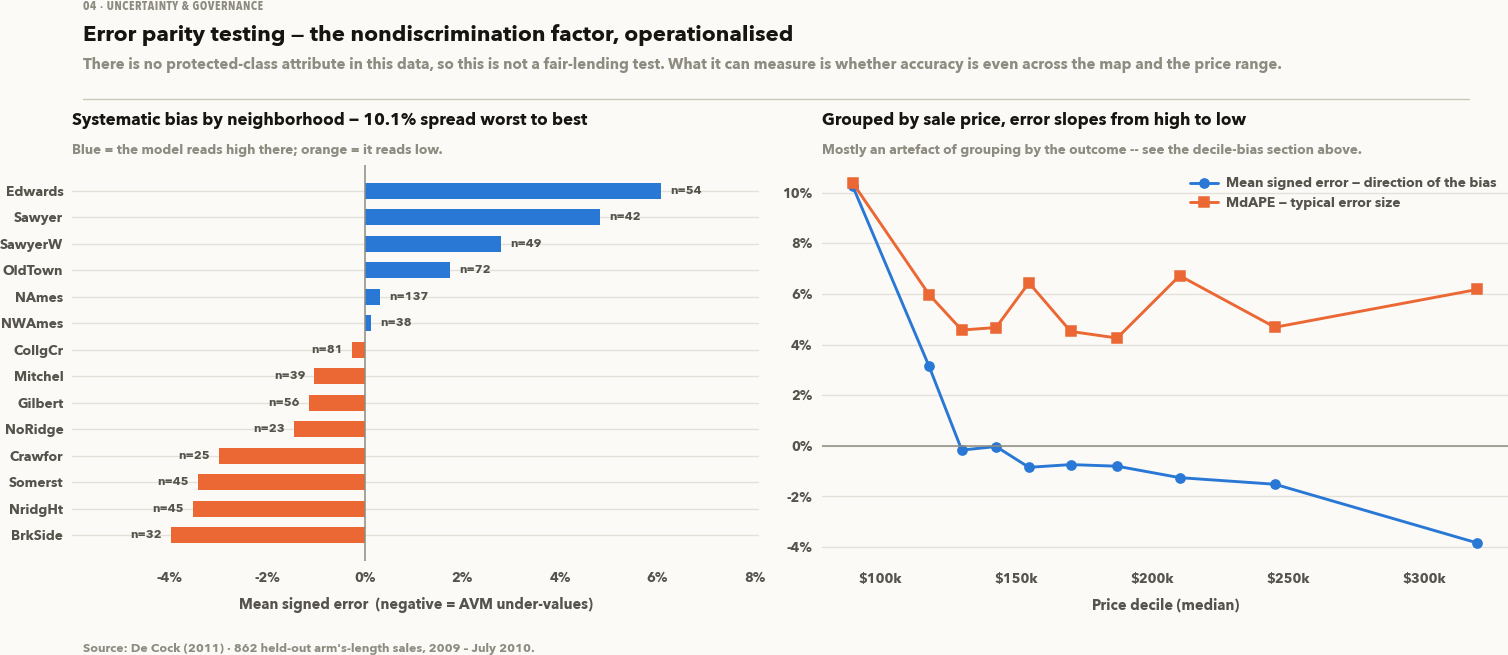

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 6.5))

order = parity_nb.sort_values("mean_signed_error")
y = np.arange(len(order))
colors = [ORANGE if v < 0 else BLUE for v in order["mean_signed_error"]]
axes[0].barh(y, order["mean_signed_error"], height=0.6, color=colors)
axes[0].set_yticks(y, order["group"], fontsize=9)
axes[0].axvline(0, color=INK_MUTED, lw=1)
axes[0].xaxis.set_major_formatter(pct)
axes[0].set_xlabel("Mean signed error  (negative = AVM under-values)")
titled(axes[0], f"Systematic bias by neighborhood — "
                f"{parity_gap(parity_nb):.1%} spread worst to best",
       "Blue = the model reads high there; orange = it reads low.")
for i, (v, n) in enumerate(zip(order["mean_signed_error"], order["n"])):
    axes[0].annotate(f"n={n}", (v, i), xytext=(6 if v >= 0 else -6, 0),
                     textcoords="offset points", fontsize=8, color=INK_SECONDARY,
                     va="center", ha="left" if v >= 0 else "right")
axes[0].margins(x=0.2)

# error_parity returns rows sorted by bias; plotting a *line* against price needs them
# in price order, or the line doubles back on itself.
decile_parity = error_parity(frame["actual"], frame["predicted"],
                             frame["price_decile"], min_n=20).sort_values("median_price")
axes[1].plot(decile_parity["median_price"], decile_parity["mean_signed_error"],
             color=BLUE, marker="o", markersize=6,
             label="Mean signed error — direction of the bias")
axes[1].plot(decile_parity["median_price"], decile_parity["MdAPE"],
             color=ORANGE, marker="s", markersize=6,
             label="MdAPE — typical error size")
axes[1].axhline(0, color=INK_MUTED, lw=1)
axes[1].xaxis.set_major_formatter(money)
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_xlabel("Price decile (median)")
axes[1].legend(loc="upper right")
titled(axes[1], "Grouped by sale price, error slopes from high to low",
       "Mostly an artefact of grouping by the outcome -- see the decile-bias section above.")

finish(fig, "Error parity testing — the nondiscrimination factor, operationalised",
       "There is no protected-class attribute in this data, so this is not a fair-lending "
       "test. What it can measure is whether accuracy is even across the map and the "
       "price range.")
save(fig, "04_error_parity")
plt.show()

In [15]:
worst = parity_nb.iloc[0]
best = parity_nb.iloc[-1]
print(f"most under-valued: {worst['group']:10s} {worst['mean_signed_error']:+.1%} "
      f"(n={worst['n']}, MdAPE {worst['MdAPE']:.1%})")
print(f"most over-valued:  {best['group']:10s} {best['mean_signed_error']:+.1%} "
      f"(n={best['n']}, MdAPE {best['MdAPE']:.1%})")
print(f"spread:            {parity_gap(parity_nb):.1%}")
print(f"MdAPE spread:      {parity_gap(parity_nb, 'MdAPE'):.1%}")

flagged = parity_nb[parity_nb["mean_signed_error"] < -0.03]
print(f"\nneighborhoods where the AVM systematically under-values by >3%: "
      f"{list(flagged['group']) if len(flagged) else 'none'}")

most under-valued: BrkSide    -4.0% (n=32, MdAPE 6.8%)
most over-valued:  Edwards    +6.1% (n=54, MdAPE 7.3%)
spread:            10.1%
MdAPE spread:      4.9%

neighborhoods where the AVM systematically under-values by >3%: ['BrkSide', 'NridgHt', 'Somerst']


The neighbourhood panel is the consequential one. Neighbourhood is observable when a
valuation is issued, so a neighbourhood whose sales are systematically mis-valued is a
bias a lender inherits: collateral in that area is consistently over- or under-stated,
and because the error is shared across the segment it does not diversify away inside a
portfolio. Notebook 08 turns that into a dollar figure.

The price-decile panel should be read with the correction in §1. Its downward slope
groups by the sale price, the quantity being estimated, and a model that is unbiased by
construction produces most of the same slope. The real over-valuation at the cheap end
is about 2–3%, and none remains at the top.

## 5. Spatial autocorrelation in the residuals

A hedonic model should have absorbed location through `Neighborhood` and the
distance features. If the residuals still cluster geographically, there is location
value it has not captured, and spatially correlated errors are correlated in the same
places as a lender's collateral.

In [16]:
resid_frame = frame.dropna(subset=["Latitude", "Longitude"]).copy()
resid_frame["log_resid"] = np.log(resid_frame["actual"]) - np.log(resid_frame["predicted"])

spatial = pd.DataFrame([
    {**morans_i(resid_frame["log_resid"], resid_frame["Latitude"],
                resid_frame["Longitude"], k=k), "neighbours": k}
    for k in (4, 8, 16)
]).set_index("neighbours")[["morans_i", "expected", "z_score", "p_value", "n"]]
spatial.round(4)

,morans_i,expected,z_score,p_value,n
neighbours,,,,,
4,0.1529,-0.0012,6.8719,0.0,859
8,0.1141,-0.0012,7.2181,0.0,859
16,0.0608,-0.0012,5.4926,0.0,859


  saved reports/figures/04_spatial_residuals.png


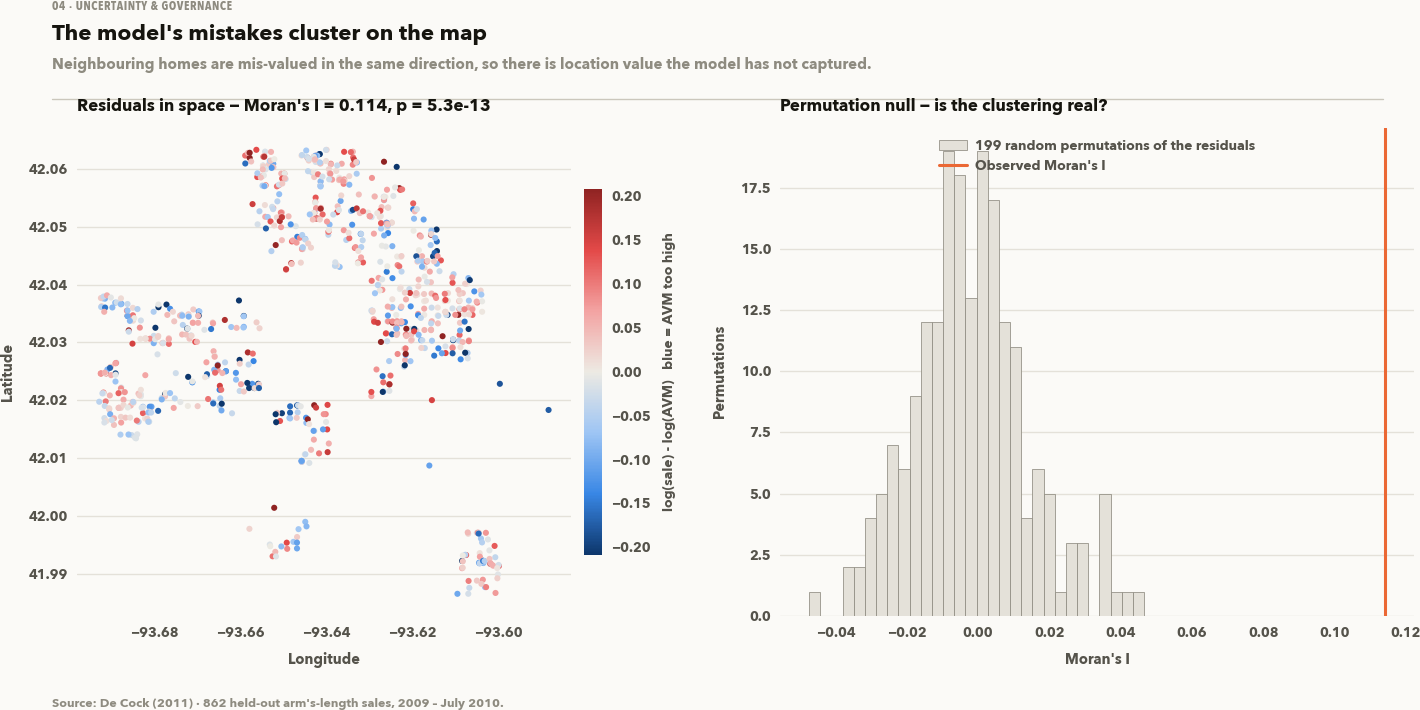

In [17]:
main = morans_i(resid_frame["log_resid"], resid_frame["Latitude"],
                resid_frame["Longitude"], k=8)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7.0))

vmax = resid_frame["log_resid"].abs().quantile(0.95)
sc = axes[0].scatter(resid_frame["Longitude"], resid_frame["Latitude"],
                     c=resid_frame["log_resid"], cmap=DIVERGING,
                     vmin=-vmax, vmax=vmax, s=16, linewidths=0)
axes[0].set_aspect(1 / np.cos(np.radians(42.03)))
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
cb = fig.colorbar(sc, ax=axes[0], shrink=0.75, pad=0.02)
cb.set_label("log(sale) - log(AVM)   blue = AVM too high", color=INK_SECONDARY, fontsize=9)
cb.outline.set_visible(False)
titled(axes[0], f"Residuals in space — Moran's I = {main['morans_i']:.3f}, "
                  f"p = {main['p_value']:.1e}")

null = []
rng = np.random.default_rng(SEED)
values = resid_frame["log_resid"].to_numpy()
for _ in range(199):
    null.append(morans_i(rng.permutation(values), resid_frame["Latitude"],
                         resid_frame["Longitude"], k=8)["morans_i"])
axes[1].hist(null, bins=30, color=GRID, edgecolor=INK_MUTED, linewidth=0.5,
             label="199 random permutations of the residuals")
axes[1].axvline(main["morans_i"], color=ORANGE, lw=2, label="Observed Moran's I")
axes[1].set_xlabel("Moran's I")
axes[1].set_ylabel("Permutations")
axes[1].legend(loc="upper center")
titled(axes[1], "Permutation null — is the clustering real?")

finish(fig, "The model's mistakes cluster on the map",
       "Neighbouring homes are mis-valued in the same direction, so there is location value "
       "the model has not captured.")
save(fig, "04_spatial_residuals")
plt.show()

In [18]:
pseudo_p = (1 + sum(v >= main["morans_i"] for v in null)) / (1 + len(null))
print(f"Moran's I (k=8): {main['morans_i']:.4f}")
print(f"normal-approximation p: {main['p_value']:.2e}")
print(f"permutation pseudo-p:   {pseudo_p:.4f}  ({len(null)} permutations)")

Moran's I (k=8): 0.1141
normal-approximation p: 5.27e-13
permutation pseudo-p:   0.0050  (199 permutations)


### What this means, and what to do about it

If Moran's I is significantly positive, the model's errors cluster: neighbouring homes
are mis-valued in the same direction. `Neighborhood` is a 28-level categorical, so it
can only capture location at the resolution of a whole subdivision. Variation within
a subdivision, and discontinuities at its boundaries, are invisible to it.

Three next steps, in priority order:

1. Spatial lag feature: the distance-weighted mean log price per square foot of the
   *k* nearest prior sales, computed with a strict time cutoff so no future sale informs
   a past valuation. This is the highest-value missing feature, and it is how
   commercial AVMs get their comparable-sales signal.
2. Geographically weighted regression or a spatially-varying coefficient model, so
   the price of a square foot can differ across the city rather than being one number.
3. A spatial block bootstrap for the accuracy intervals. With correlated residuals,
   the standard errors on MdAPE above are too narrow, because the effective sample size is
   smaller than 862.

This appears in a governance notebook rather than a modelling one because spatially
correlated valuation error is a concentration risk. A portfolio of loans in one city,
valued by one AVM with clustered errors, does not get the diversification its loan count
implies.

## 6. Persist for notebook 08

In [19]:
conformal_artifacts = {
    regime: {
        "alpha": CONFORMAL_ALPHA,
        "q": float(r["conformal"].q_),
        "relative_width": float(r["conformal"].relative_width),
        "empirical_coverage": float(r["coverage"]),
        "smearing": float(r["smearing"]),
        "mean_coverage_resampled": float(
            repeat_summary.loc[f"{regime} (fixed test set)", "mean_coverage"]),
        "coverage_sd_resampled": float(
            repeat_summary.loc[f"{regime} (fixed test set)", "sd"]),
    } for regime, r in conformal.items()
}

# The Mondrian calibrator serving uses: its bands, and how each performed on the
# temporal holdout.  Band coverage is one split of ~170 sales per band, so it carries a
# ~3-point binomial standard error; the 25-split means above are the stable figures.
served = conformal["temporal"]
mondrian = served["mondrian"]
band = mondrian.band(served["log_pred"])
inside = (served["actual"] >= served["m_lo"]) & (served["actual"] <= served["m_hi"])
q_row = mondrian.half_width(served["log_pred"])
conformal_artifacts["temporal"]["mondrian"] = {
    **mondrian.to_dict(),
    "relative_width_by_band": [float(np.exp(q) - np.exp(-q)) for q in mondrian.to_dict()["q_by_band"]],
    "coverage_by_band": [float(inside[band == b].mean()) for b in range(MONDRIAN_BINS)],
    "n_test_by_band": [int((band == b).sum()) for b in range(MONDRIAN_BINS)],
    "empirical_coverage": float(served["mondrian_coverage"]),
    "relative_width": float(np.mean(np.exp(q_row) - np.exp(-q_row))),
    "mean_coverage_resampled": float(adaptive.loc["Mondrian · value", "coverage"]),
    "coverage_sd_resampled": float(adaptive_sd.loc["Mondrian · value", "coverage"]),
    "mean_relative_width_resampled": float(adaptive.loc["Mondrian · value", "relative_width"]),
}
print(pd.DataFrame({
    "valuation from": np.exp(mondrian.edges_[:-1]).round(-3),
    "valuation to": np.exp(mondrian.edges_[1:]).round(-3),
    "half-width q": mondrian.to_dict()["q_by_band"],
    "range, % of value": conformal_artifacts["temporal"]["mondrian"]["relative_width_by_band"],
    "holdout coverage": conformal_artifacts["temporal"]["mondrian"]["coverage_by_band"],
    "holdout n": conformal_artifacts["temporal"]["mondrian"]["n_test_by_band"],
}).round(4).to_string())
(PROCESSED / "conformal.json").write_text(json.dumps(conformal_artifacts, indent=2))

frame.assign(PID=universe.loc[frame.index, "PID"].to_numpy()).to_parquet(
    PROCESSED / "avm_intervals.parquet", index=False)

(PROCESSED / "governance_summary.json").write_text(json.dumps({
    "model": MODEL,
    "mdape": float(card["MdAPE"]),
    "ppe10": float(card["PPE10"]),
    "fsd": float(card["FSD"]),
    "mean_signed_error": float(card["mean_signed_error"]),
    "conformal_coverage_temporal": float(repeat_summary.loc["temporal (fixed test set)", "mean_coverage"]),
    "conformal_coverage_random_full_resample": float(
        repeat_summary.loc["random (full resample)", "mean_coverage"]),
    "conformal_coverage_single_split_temporal": float(conformal["temporal"]["coverage"]),
    "interval_relative_width": float(conformal["temporal"]["conformal"].relative_width),
    "neighborhood_bias_spread": float(parity_gap(parity_nb)),
    "morans_i": float(main["morans_i"]),
    "morans_p": float(main["p_value"]),
    "bottom_decile_bias": float(by_decile.loc[0, "bias"]),
    "top_decile_bias": float(by_decile.loc[9, "bias"]),
    # The two decile-bias figures above group by the *sale price*.  These say how much of
    # that is the grouping: the same errors grouped by valuation, and what a model that is
    # unbiased by construction shows under the sale-price grouping.
    "bias_by_valuation_max_abs": float(bias_by_valuation.abs().max()),
    "bias_artefact_bottom": float(bias_artefact.iloc[0]),
    "bias_artefact_top": float(bias_artefact.iloc[-1]),
    "bias_artefact_bottom_homoskedastic": float(bias_artefact_homo.iloc[0]),
    "adaptive_intervals": {
        method: {metric: float(adaptive.loc[method, metric]) for metric in METRICS}
        for method in METHOD_ORDER
    },
}, indent=2))
print("\nwrote conformal.json, avm_intervals.parquet, governance_summary.json")

   valuation from  valuation to  half-width q  range, % of value  holdout coverage  holdout n
0         60000.0      122000.0        0.1477             0.2965            0.7823        147
1        122000.0      143000.0        0.0882             0.1767            0.7212        165
2        143000.0      174000.0        0.0960             0.1923            0.7828        198
3        174000.0      210000.0        0.0851             0.1704            0.7310        145
4        210000.0      478000.0        0.1137             0.2278            0.8019        207

wrote conformal.json, avm_intervals.parquet, governance_summary.json


## 7. Summary

| Finding | Consequence |
|---|---|
| Averaged over calibration draws, random-split coverage lands on nominal | The interval method is sound; a single-split coverage number does not validate it |
| Coverage degrades under the temporal split, as exchangeability predicts | Notebook 05 re-fits the interval quarterly on the last twelve months, lifting backtested coverage from 76.7% to 78.8% |
| Interval width is a constant *ratio* of value | Expensive collateral carries more dollar uncertainty, the LGD input in nb 08 |
| MdAPE misses the 5% institutional bar; PPE10 clears 75% | Reported as measured distance from the bar, not as a pass |
| Systematic bias varies across neighbourhoods (10.1% spread) | The transmission channel into LTV, quantified in nb 08 |
| The price-decile "bias" is mostly the measurement: +2.7% unexplained at the cheap end, none at the top | The 10.2% / −3.8% figures are withdrawn; the client-report price-band flag is removed |
| Mondrian conformal by valuation lifts the cheapest decile's coverage from 51% to 63% at +0.6 pt width; CQR restores 80% marginal at +37% width | Mondrian by valuation is the served interval, re-fitted quarterly (notebook 05) |
| Residuals are spatially autocorrelated | A prioritised list of next steps (§5) |